# Code for generating time-series synthetic data

In [1]:
#Generate dataset
import sys
import os
import numpy as np
sys.path.append(os.path.abspath('..')) 
from cpbge.data import generate_synthetic_data_2node, generate_synthetic_data_4node

num_timepoints = 100

def generate_synthetic_data_2node_multicps(num_time_points=100, epsilon=0.5, snr=50):
    """Modified: 2-node network (X → X and X → Y) with 5 change points"""
    np.random.seed(42)
    m = num_time_points
    X = np.zeros(m)
    Y = np.zeros(m)
    phi_X = np.random.normal(0, 1, m)
    phi_Y = np.random.normal(0, 1, m)

    X[0] = np.random.normal(0, 1)
    beta = np.ones(m)

    # Define 5 equal segments
    segment_edges = np.linspace(0, m, 6, dtype=int)  # 6 points = 5 segments
    change_points = segment_edges[1:-1]  # inner edges are the CPs

    # Assign different beta values to each segment
    beta[segment_edges[0]:segment_edges[1]] = 2
    beta[segment_edges[1]:segment_edges[2]] = -2
    beta[segment_edges[2]:segment_edges[3]] = 2
    beta[segment_edges[3]:segment_edges[4]] = -1
    beta[segment_edges[4]:segment_edges[5]] = 1

    # Generate X (autoregressive)
    for t in range(1, m):
        X[t] = np.sqrt(1 - epsilon ** 2) * X[t - 1] + epsilon * phi_X[t]

    # Scale noise
    sigma_beta_X = np.std(beta * X)
    c = sigma_beta_X / snr

    # Generate Y (influenced by beta * X + noise)
    for t in range(m - 1):
        Y[t + 1] = beta[t] * X[t] + c * phi_Y[t + 1]

    data = np.vstack([X, Y])
    true_cps = [change_points.tolist(), change_points.tolist()]  # CPs for both X and Y
    return data, true_cps


# Uncomment the next line to generate a 4-node dataset
# data, true_cps = generate_synthetic_data_4node(num_time_points=num_timepoints)
# node_names = ["X", "Y", "Z", "W"]
# Uncomment the next lines to generate a 2-node dataset
data, true_cps = generate_synthetic_data_2node_multicps(num_time_points=num_timepoints)
node_names = ["X", "Y"]

Learned Edge Probabilities (edges with prob > 0.5):
  Edge X → X: 1.000
  Edge X → Y: 0.998
Changepoints
  Node X: [] (K = 1)
  Node Y: [20, 40, 59, 73, 79] (K = 6)
Learned Change Points: [[20, 40, 59, 73, 79], [20, 40, 59, 73, 79]]


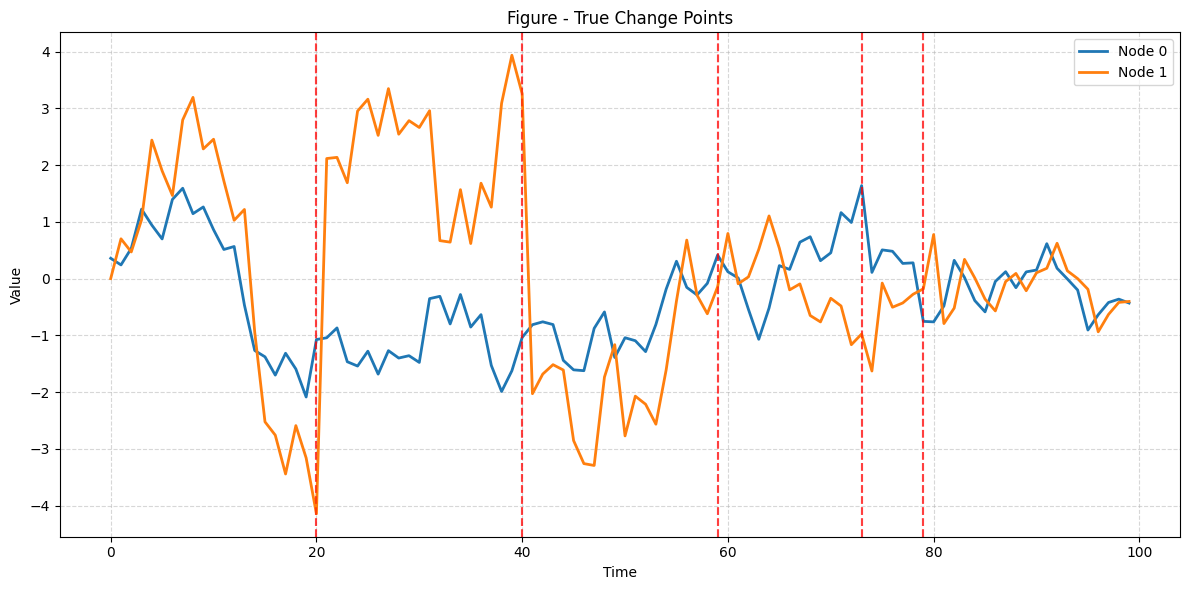

In [2]:
#Find change points
# This script performs MCMC inference on synthetic data, identifies change points,
# and splits the data into segments based on these change points.
import numpy as np
import pandas as pd
from cpbge.mcmc import MCMC
from cpbge.plotting import plot_time_series_with_changepoints
from collections import defaultdict


def print_learned_structure(edge_probs, mean_K, allocation, node_names=None):
    """Prints edges and change points using readable node labels."""
    if node_names is None:
        node_names = [str(i) for i in range(len(mean_K))]

    print("Learned Edge Probabilities (edges with prob > 0.5):")
    for (u, v), prob in edge_probs.items():
        if prob > 0.5:
            print(f"  Edge {node_names[u]} → {node_names[v]}: {prob:.3f}")

    print("Changepoints")
    for node in range(allocation.shape[0]):
        cps = np.where(allocation[node, 1:] != allocation[node, :-1])[0]
        print(f"  Node {node_names[node]}: {cps.tolist()} (K = {len(cps)+1})")
    return cps

def split_dataframe_at_change_points(df, change_points):
    """
    Splits a DataFrame into segments at the given change points.

    Parameters:
        df (pd.DataFrame): The DataFrame to split.
        change_points (list of lists): Nested list of change points (e.g., [[33, 65], [33, 65]])

    Returns:
        list of pd.DataFrame: A list of DataFrame segments.
    """
    # Step 1: Flatten and deduplicate change points
    flat_points = sorted(set(point for sublist in change_points for point in sublist))
    
    # Step 2: Add start and end bounds
    indices = [0] + flat_points + [len(df)]
    
    # Step 3: Split the DataFrame
    segments = [df.iloc[indices[i]:indices[i+1]] for i in range(len(indices) - 1)]
    
    return segments

# MCMC
model = MCMC(num_nodes=data.shape[0], max_segments=5)
edge_probs, mean_K, allocation, samples = model.mcmc_inference(
    data, num_iterations=1000000, burn_in=1000
)

# Extract K_samples from samples
K_samples = [s[2] for s in samples]  # each sample is (graph, allocation, K)

# Output with labels
learnt_cps = print_learned_structure(edge_probs, mean_K, allocation, node_names=node_names)

#Make learnt cps into a list containg cps for all variables
learnt_cps=[learnt_cps.tolist()]*len(node_names)
print("Learned Change Points:", learnt_cps)

# Plot
plot_time_series_with_changepoints(data, learnt_cps, title=f"Figure - True Change Points")

data_df = pd.DataFrame(data[:,:].T, columns=node_names)


In [3]:
# Get structure of learnt Bayesian network

# Build child-to-parents mapping
child_parents = defaultdict(list)

for (u, v), prob in edge_probs.items():
    if prob > 0.5:
        child_parents[v].append(u)

# Convert to desired format with names
bayesian_structure = [
    [node_names[child], [node_names[parent] for parent in parents]]
    for child, parents in child_parents.items()
]

#bayesian_structure = [['X', ['X']], ['Y', ['X_t-1']]]
print(bayesian_structure)

[['X', ['X']], ['Y', ['X']]]


In [4]:
# Modify the DataFrame to include t-1 versions if they exist
def apply_temporal_shift(df, bayesian_structure):
    """
    Detects self-parenting nodes and modifies the DataFrame to include t-1 versions.
    
    Args:
        df (pd.DataFrame): Original data.
        bayesian_structure (list): List of [child, [parent1, parent2, ...]].

    Returns:
        pd.DataFrame: Modified DataFrame with _t-1 columns.
        list: Updated Bayesian structure.
    """
    updated_structure = []

    for child, parents in bayesian_structure:
        new_parents = []
        for parent in parents:
            if parent == child:
                # Create lagged column
                print(f"Creating lagged column for self-parenting node: {child}")
                lagged_col = f"{parent}_t-1"
                if lagged_col not in df.columns:
                    df[lagged_col] = df[parent].shift(1)  # Shift values down by 1
                new_parents.append(lagged_col)
            else:
                new_parents.append(parent)
        updated_structure.append([child, new_parents])

    # Drop the first row with NaN due to shift (optional, depending on use case)
    df = df.dropna().reset_index(drop=True)

    return df, updated_structure

new_df, new_structure = apply_temporal_shift(data_df, bayesian_structure)


print(new_structure)

# Split the updated DataFrame
segments = split_dataframe_at_change_points(new_df, learnt_cps)
for segment in segments:
    print(segment.head())  # Print the first few rows of each segment

print(learnt_cps)

Creating lagged column for self-parenting node: X
[['X', ['X_t-1']], ['Y', ['X']]]
          X         Y     X_t-1
0  0.240721  0.700600  0.357787
1  0.532315  0.469241  0.240721
2  1.222513  1.036068  0.532315
3  0.941651  2.439284  1.222513
4  0.698425  1.897685  0.941651
           X         Y     X_t-1
20 -1.042664  2.114852 -1.073613
21 -0.869210  2.135267 -1.042664
22 -1.465132  1.688514 -0.869210
23 -1.541033  2.951155 -1.465132
24 -1.279112  3.160045 -1.541033
           X         Y     X_t-1
40 -0.812604 -2.027974 -1.037254
41 -0.761560 -1.682434 -0.812604
42 -0.810082 -1.516547 -0.761560
43 -1.440813 -1.610913 -0.810082
44 -1.607702 -2.853793 -1.440813
           X         Y     X_t-1
59  0.119550  0.794694  0.414696
60  0.010704 -0.091530  0.119550
61 -0.543897  0.030541  0.010704
62 -1.069132  0.514681 -0.543897
63 -0.519633  1.103428 -1.069132
           X         Y     X_t-1
73  0.108924 -1.628435  1.638285
74  0.505282 -0.079476  0.108924
75  0.481110 -0.504819  0.505282

In [5]:
# Get conditional probability tables (CPTs) for the Bayesian network
# Use DataSynthesizer1 to describe the datasets and convert description to CPTs
from DataSynthesizer1.DataDescriber import DataDescriber
from DataSynthesizer1.lib.utils import read_json_file, display_bayesian_network

epsilon = 1.0

for segment in segments:
    print(f"Synthesizing segment with shape {segment.shape}")
    # Get description for each segment
    # Note: You may want to adjust epsilon based on your requirements
    # or use a different epsilon for each segment if needed.
    describer = DataDescriber(bayesian_network=new_structure, category_threshold=16)
    segment.to_csv("temp_segment.csv", index=False)
    describer.describe_dataset_in_correlated_attribute_mode("temp_segment.csv", epsilon=epsilon)
    describer.save_dataset_description_to_file(f"dataset_description_{segment.index[0]}_{segment.index[-1]}.json")
    display_bayesian_network(describer.bayesian_network)
    
import json

def parse_conditional_probabilities(cond_probs, structure):
    """
    Converts conditional probabilities from JSON to readable DataFrames using known structure.

    Args:
        cond_probs (dict): Dictionary of conditional probabilities.
        structure (list): List of [child, [parents]] describing the Bayesian network.

    Returns:
        dict: Mapping from variable name to formatted DataFrame.
    """
    tables = {}

    # Build mapping from variable to parent
    parent_map = {child: parents[0] if parents else None for child, parents in structure}

    for child_var, value in cond_probs.items():
        parent_var = parent_map.get(child_var)

        if isinstance(value, list):
            # Marginal probability: P(child_var)
            df = pd.DataFrame({
                child_var: list(range(len(value))),
                f"P({child_var})": value
            })
            tables[child_var] = df

        elif isinstance(value, dict) and parent_var:
            # Conditional probability: P(child_var | parent_var)
            records = []
            for parent_val, probs in value.items():
                parent_val_index = int(parent_val.strip("[]"))
                row = {parent_var: parent_val_index}
                row.update({
                    f"P({child_var}={i} | {parent_var}={parent_val_index})": p
                    for i, p in enumerate(probs)
                })
                records.append(row)

            df = pd.DataFrame(records)    
            tables[child_var] = df

        else:
            raise ValueError(f"Unsupported format for variable '{child_var}'")

    return tables

all_tables = {}  # (segment_id, variable) -> DataFrame

for i, segment in enumerate(segments):
    start, end = segment.index[0], segment.index[-1]
    segment_id = f"{start}_{end}"

    with open(f"dataset_description_{start}_{end}.json") as f:
        data = json.load(f)

    cond_probs = data["conditional_probabilities"]
    tables = parse_conditional_probabilities(cond_probs, new_structure)
    os.remove(f"dataset_description_{start}_{end}.json")  # Clean up temporary file
    # Store each table with a segment identifier
    for var, df in tables.items():
        all_tables[(segment_id, var)] = df

grouped_by_var = defaultdict(list)

for (segment_id, var), df in all_tables.items():
    grouped_by_var[var].append(df)
    cols_to_drop = [col for col in df.columns if not col.startswith("P(")]
    df.drop(columns=cols_to_drop, inplace=True)


for df in grouped_by_var.items():
    var_name, dfs = df
    print(df)

Synthesizing segment with shape (20, 3)
Constructed Bayesian network:
    X has parents ['X_t-1'].
    Y has parents ['X'].
Synthesizing segment with shape (20, 3)
Constructed Bayesian network:
    X has parents ['X_t-1'].
    Y has parents ['X'].
Synthesizing segment with shape (19, 3)
Constructed Bayesian network:
    X has parents ['X_t-1'].
    Y has parents ['X'].
Synthesizing segment with shape (14, 3)
Constructed Bayesian network:
    X has parents ['X_t-1'].
    Y has parents ['X'].
Synthesizing segment with shape (6, 3)
Constructed Bayesian network:
    X has parents ['X_t-1'].
    Y has parents ['X'].
Synthesizing segment with shape (20, 3)
Constructed Bayesian network:
    X has parents ['X_t-1'].
    Y has parents ['X'].
('X_t-1', [    P(X_t-1)
0   0.045962
1   0.024256
2   0.062680
3   0.027746
4   0.083293
5   0.051448
6   0.031172
7   0.043090
8   0.040957
9   0.048829
10  0.084323
11  0.062225
12  0.031444
13  0.019905
14  0.035959
15  0.054079
16  0.056530
17  0.029112

In [6]:
# Compute Wasserstein distance of CPTs across segments
import numpy as np
from scipy.stats import wasserstein_distance

def compute_wasserstein_matrix_df(tables, epsilon=1e-8):
    n = len(tables)
    labels = [getattr(t, 'name', f'Table_{i}') for i, t in enumerate(tables)]
    wd_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            df1 = tables[i]
            df2 = tables[j]
            if df1.shape[0] == 0 or df2.shape[0] == 0:
                wd_matrix[i, j] = wd_matrix[j, i] = np.nan
                continue
            if df1.shape[1] != df2.shape[1]:
                print(df1)
                print(df2)
            if df1.empty or df2.empty:
                wd_matrix[i, j] = wd_matrix[j, i] = np.nan
                continue
            prob_cols = [col for col in df1.columns if col.startswith("P(")]
            wd_values = []

            min_rows = min(len(df1), len(df2))  # <-- fix here

            for k in range(min_rows):
                row1 = df1[prob_cols].iloc[k].values
                row2 = df2[prob_cols].iloc[k].values

                if np.isnan(row1).all() or np.isnan(row2).all():
                    continue

                p = np.nan_to_num(row1, nan=epsilon)
                q = np.nan_to_num(row2, nan=epsilon)
                p /= p.sum()
                q /= q.sum()

                positions = np.arange(len(p))
                wd = wasserstein_distance(positions, positions, u_weights=p, v_weights=q)
                wd_values.append(wd)

            if wd_values:
                avg_wd = np.mean(wd_values)
                wd_matrix[i, j] = wd_matrix[j, i] = avg_wd
            else:
                wd_matrix[i, j] = wd_matrix[j, i] = np.nan

    return pd.DataFrame(wd_matrix, index=labels, columns=labels)


wasserstein_distance_by_var = {
    var: compute_wasserstein_matrix_df(tables)
    for var, tables in grouped_by_var.items()
}

for var, wd_df in wasserstein_distance_by_var.items():
    print(f"Wasserstein Distance for {var}:")
    print(wd_df)
    print("\n")


    P(X=0 | X_t-1=0)  P(X=1 | X_t-1=0)  P(X=2 | X_t-1=0)  P(X=3 | X_t-1=0)  \
0                0.0               0.0          0.039301               0.0   
1                NaN               NaN               NaN               NaN   
2                NaN               NaN               NaN               NaN   
3                NaN               NaN               NaN               NaN   
4                NaN               NaN               NaN               NaN   
5                NaN               NaN               NaN               NaN   
6                NaN               NaN               NaN               NaN   
7                NaN               NaN               NaN               NaN   
8                NaN               NaN               NaN               NaN   
9                NaN               NaN               NaN               NaN   
10               NaN               NaN               NaN               NaN   
11               NaN               NaN               NaN        

KeyError: "['P(X=14 | X_t-1=0)', 'P(X=15 | X_t-1=0)', 'P(X=16 | X_t-1=0)', 'P(X=17 | X_t-1=0)', 'P(X=18 | X_t-1=0)', 'P(X=19 | X_t-1=0)', 'P(X=14 | X_t-1=1)', 'P(X=15 | X_t-1=1)', 'P(X=16 | X_t-1=1)', 'P(X=17 | X_t-1=1)', 'P(X=18 | X_t-1=1)', 'P(X=19 | X_t-1=1)', 'P(X=14 | X_t-1=2)', 'P(X=15 | X_t-1=2)', 'P(X=16 | X_t-1=2)', 'P(X=17 | X_t-1=2)', 'P(X=18 | X_t-1=2)', 'P(X=19 | X_t-1=2)', 'P(X=14 | X_t-1=3)', 'P(X=15 | X_t-1=3)', 'P(X=16 | X_t-1=3)', 'P(X=17 | X_t-1=3)', 'P(X=18 | X_t-1=3)', 'P(X=19 | X_t-1=3)', 'P(X=14 | X_t-1=4)', 'P(X=15 | X_t-1=4)', 'P(X=16 | X_t-1=4)', 'P(X=17 | X_t-1=4)', 'P(X=18 | X_t-1=4)', 'P(X=19 | X_t-1=4)', 'P(X=14 | X_t-1=5)', 'P(X=15 | X_t-1=5)', 'P(X=16 | X_t-1=5)', 'P(X=17 | X_t-1=5)', 'P(X=18 | X_t-1=5)', 'P(X=19 | X_t-1=5)', 'P(X=14 | X_t-1=6)', 'P(X=15 | X_t-1=6)', 'P(X=16 | X_t-1=6)', 'P(X=17 | X_t-1=6)', 'P(X=18 | X_t-1=6)', 'P(X=19 | X_t-1=6)', 'P(X=14 | X_t-1=7)', 'P(X=15 | X_t-1=7)', 'P(X=16 | X_t-1=7)', 'P(X=17 | X_t-1=7)', 'P(X=18 | X_t-1=7)', '

Clustering for X_t-1:
Cluster labels: [0 0 0 0 0]


Clustering for X:


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Cluster labels: [1 0 1 1 1]


Clustering for Y:
Cluster labels: [0 0 0 1 0]


[2 1 1 1 1]


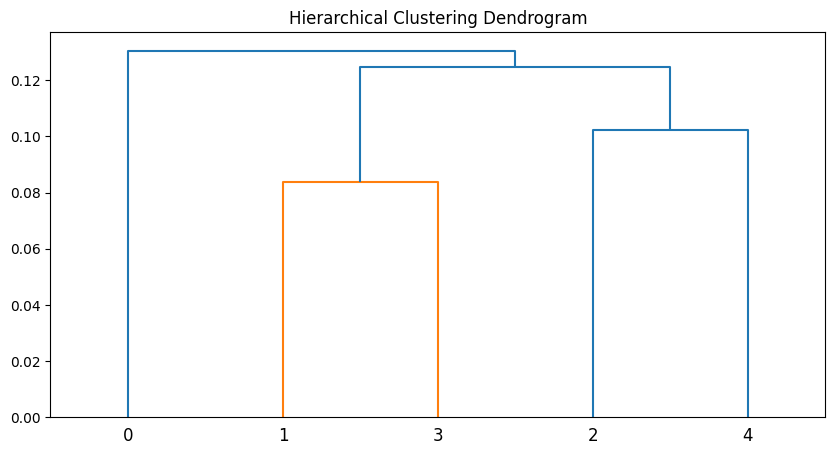

In [ ]:
# K-means clustering on flattened probability distributions and hierarchical clustering with 2 clusters
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def impute_normalize_flatten(df, prob_cols, epsilon=1e-8):
    df_copy = df.copy()
    # Impute NaNs with epsilon
    df_copy[prob_cols] = df_copy[prob_cols].fillna(epsilon)
    # Normalize rows to sum to 1
    row_sums = df_copy[prob_cols].sum(axis=1)
    df_copy[prob_cols] = df_copy[prob_cols].div(row_sums, axis=0)
    # Flatten to 1D vector
    return df_copy[prob_cols].values.flatten()

def kmeans_on_flattened(tables, prob_cols=None, epsilon=1e-8, n_clusters=3):
    if prob_cols is None:
        prob_cols = [col for col in tables[0].columns if col.startswith("P(")]

    data_vectors = np.array([impute_normalize_flatten(df, prob_cols, epsilon) for df in tables])

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(data_vectors)

    return labels

# Example usage
for var, tables in grouped_by_var.items():
    print(f"Clustering for {var}:")
    labels = kmeans_on_flattened(tables, n_clusters=2)
    print("Cluster labels:", labels)
    print("\n")

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

def hierarchical_clustering(distance_matrix, n_clusters=2):
    # linkage expects condensed distance matrix (upper triangular)
    condensed = squareform(distance_matrix, checks=False)
    Z = linkage(condensed, method='average')
    labels = fcluster(Z, n_clusters, criterion='maxclust')
    return labels, Z

# Compute distance matrix (example: Wasserstein distance matrix)
distance_matrix = compute_wasserstein_matrix_df(tables)

labels, Z = hierarchical_clustering(distance_matrix)

print(labels)

# Optionally plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()


In [ ]:
from sklearn.mixture import BayesianGaussianMixture

def fit_vbgmm_elbo(tables, var, epsilon=1e-8, max_clusters=10, random_state=42):
    # Only use CPTs where this variable is in the head
    prob_cols = [col for col in tables[0].columns if col.startswith(f"P({var}")]

    data_vectors = np.array([impute_normalize_flatten(df, prob_cols, epsilon) for df in tables])

    elbos = []
    models = []

    n_samples = len(tables)
    max_k = min(max_clusters, n_samples)

    for k in range(1, max_k + 1):
        vbgmm = BayesianGaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
        vbgmm.fit(data_vectors)
        elbos.append(vbgmm.lower_bound_ /n_samples)  # Normalize by number of samples
        models.append(vbgmm)
        print(f"ELBO for {k} clusters: {vbgmm.lower_bound_ / n_samples}")

    plt.plot(range(1, len(elbos) + 1), elbos, marker='o')
    plt.xlabel('Number of clusters')
    plt.ylabel('ELBO (Variational Lower Bound)')
    plt.title(f'ELBO vs Number of Clusters for Variable {var}')
    plt.show()

    best_idx = np.argmax(elbos)
    best_model = models[best_idx]

    return best_model, best_idx + 1

# Usage example:
for var, tables in grouped_by_var.items():
    print(f"Estimating number of clusters for variable: {var}")
    best_model, best_k = fit_vbgmm_elbo(tables, var=var)
    labels = best_model.predict(np.array([impute_normalize_flatten(df, [col for col in tables[0].columns if col.startswith("P(")]) for df in tables]))
    print(f"Best number of clusters for {var}: {best_k}")
    print(f"Cluster labels for {var}:", labels)
    print("\n")

Estimating number of clusters for variable: X_t-1
ELBO for 1 clusters: 17.721028125416353
ELBO for 2 clusters: 24.643162474640608
ELBO for 3 clusters: 32.416717321767244
ELBO for 4 clusters: 41.98304825830401


/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:653: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning

ELBO for 5 clusters: 53.44214568754357


/opt/homebrew/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


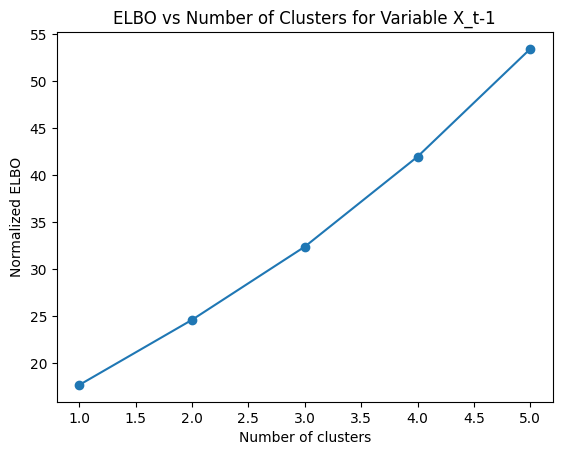

Cluster labels for X_t-1: [0 0 0 0 0]


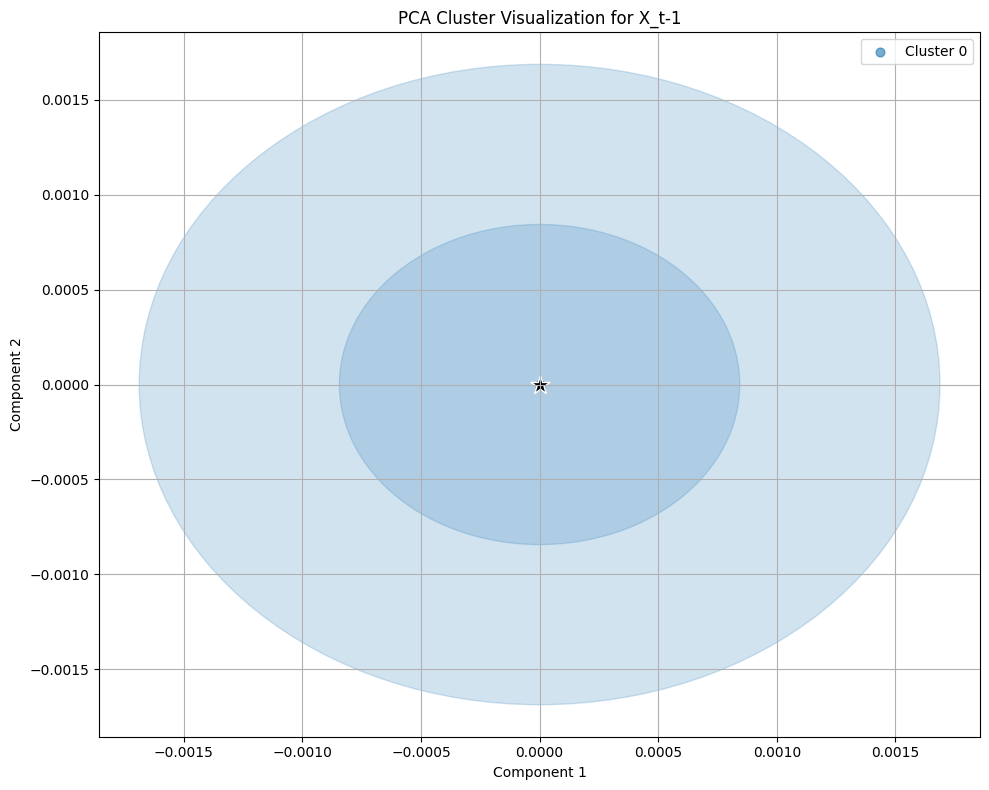

Estimating number of clusters for variable: X
ELBO for 1 clusters: 6.797646050793739
ELBO for 2 clusters: 9.670065831216696
ELBO for 3 clusters: 12.837362099061426
ELBO for 4 clusters: 16.062891012963185
ELBO for 5 clusters: 19.86803869561097


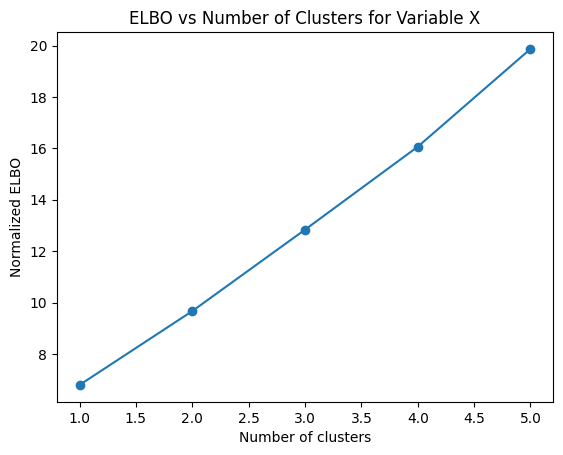

Cluster labels for X: [0 0 0 0 0]


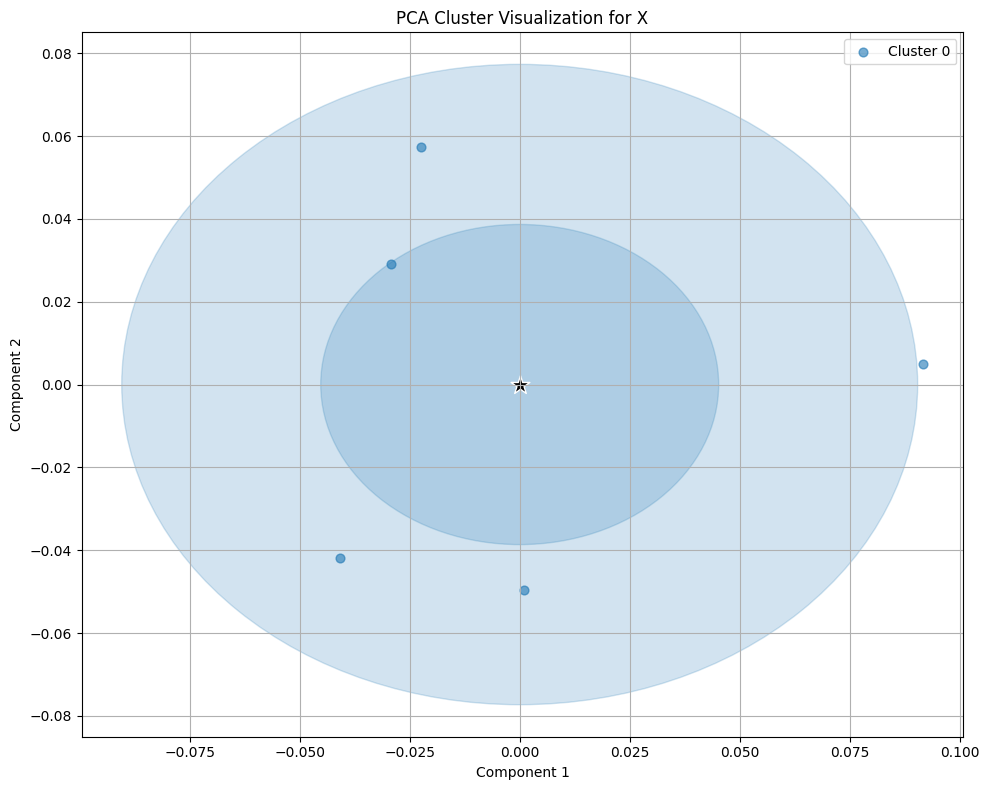

Estimating number of clusters for variable: Y
ELBO for 1 clusters: 6.798975615087665
ELBO for 2 clusters: 9.927964964272016
ELBO for 3 clusters: 13.10957525906259
ELBO for 4 clusters: 16.343595322563957
ELBO for 5 clusters: 19.624520178920157


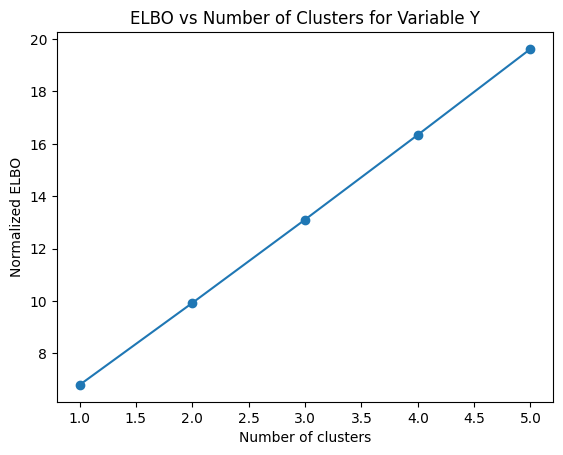

Cluster labels for Y: [0 0 0 1 0]


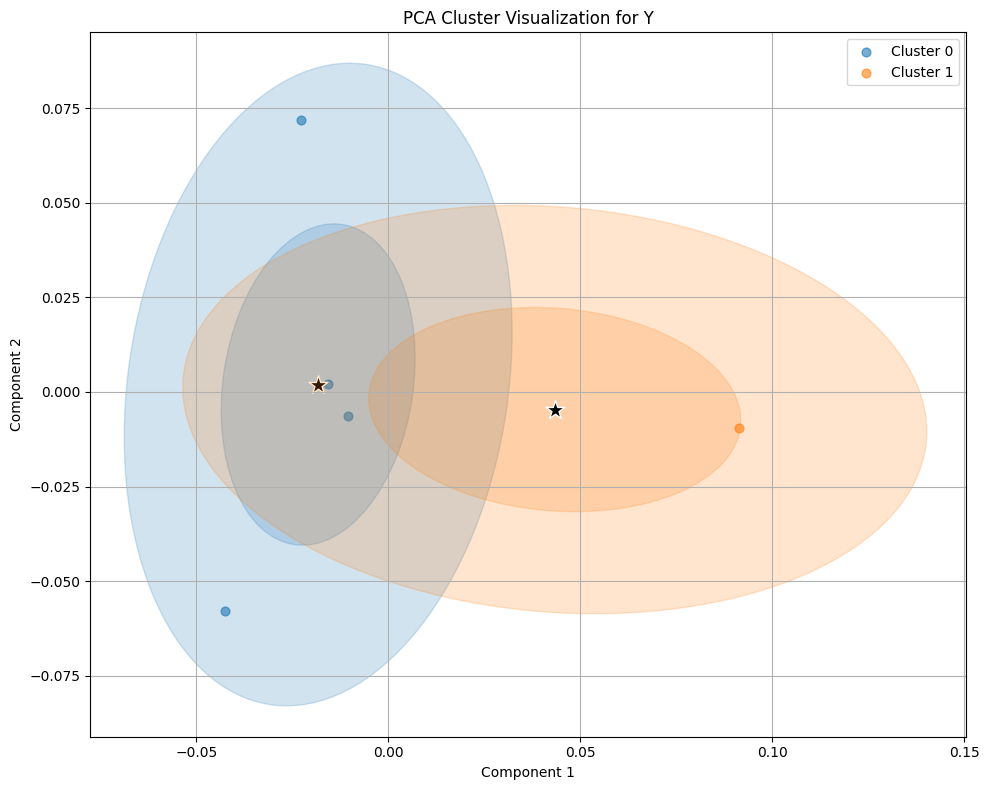

In [ ]:

import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture
from matplotlib.patches import Ellipse
         
# def fit_vbgmm_elbo(tables, var, epsilon=1e-8, max_clusters=len(tables), random_state=42):
#     # Only use CPTs where this variable is in the head
#     prob_cols = [col for col in tables[0].columns if col.startswith(f"P({var}")]

#     data_vectors = np.array([impute_normalize_flatten(df, prob_cols, epsilon) for df in tables])

#     elbos = []
#     models = []

#     n_samples = len(tables)
#     max_k = min(max_clusters, n_samples)

#     for k in range(1, max_k + 1):
#         vbgmm = BayesianGaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
#         vbgmm.fit(data_vectors)
#         elbos.append(vbgmm.lower_bound_ /n_samples)  # Normalize by number of samples
#         models.append(vbgmm)
#         print(f"ELBO for {k} clusters: {vbgmm.lower_bound_ / n_samples}")

#     plt.plot(range(1, len(elbos) + 1), elbos, marker='o')
#     plt.xlabel('Number of clusters')
#     plt.ylabel('ELBO (Variational Lower Bound)')
#     plt.title(f'ELBO vs Number of Clusters for Variable {var}')
#     plt.show()

#     best_idx = np.argmax(elbos)
#     best_model = models[best_idx]

#     return best_model, best_idx + 1

# for var, tables in grouped_by_var.items():
#     print(f"Estimating number of clusters for variable: {var}")
#     best_model, best_k = fit_vbgmm_elbo(tables, var=var)
    
#     prob_cols = [col for col in tables[0].columns if col.startswith("P(")]
#     data_vectors = np.array([impute_normalize_flatten(df, prob_cols) for df in tables])
#     labels = best_model.predict(data_vectors)

#     print(f"Cluster labels for {var}:", labels)

#     visualize_clusters(tables, labels, best_model, method='pca', title=f'PCA Cluster Visualization for {var}')


from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal

def fit_vbgmm_elbo(tables, var, epsilon=1e-8, max_clusters=None, n_components=2, random_state=42):
    from sklearn.decomposition import PCA
    import numpy as np
    """
    Fits Bayesian Gaussian Mixture Models to CPTs of a variable using ELBO and optional dimensionality reduction.
    
    Parameters:
        tables: List of DataFrames (CPTs).
        var: Variable name to extract "P(var" columns.
        epsilon: Small value to avoid divide-by-zero.
        max_clusters: Max number of clusters to test. Defaults to number of tables.
        random_state: Seed for reproducibility.
        reduce_dim: Whether to reduce dimension before clustering.
        n_components: Number of dimensions to reduce to (PCA).
        
    Returns:
        best_model: Trained BayesianGaussianMixture model with best ELBO.
        best_k: Number of components for best_model.
        reduced_data: The transformed feature matrix (after PCA if applied).
        reducer: The PCA model used (or None).
    """
    prob_cols = [col for col in tables[0].columns if col.startswith(f"P({var}")]

    data_vectors = np.array([
        impute_normalize_flatten(df, prob_cols, epsilon) for df in tables
    ])

    if max_clusters is None:
        max_clusters = len(tables)

    # Step 1: Reduce dimensions BEFORE modeling
    reducer = PCA(n_components=n_components)
    reduced_data = reducer.fit_transform(data_vectors)

    elbos = []
    models = []

    for k in range(1, min(max_clusters, len(tables)) + 1):
        model = BayesianGaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
        model.fit(reduced_data)
        elbos.append(model.lower_bound_ / len(tables))
        models.append(model)
        print(f"ELBO for {k} clusters: {model.lower_bound_ / len(tables)}")

    plt.plot(range(1, len(elbos) + 1), elbos, marker='o')
    plt.xlabel('Number of clusters')
    plt.ylabel('Normalized ELBO')
    plt.title(f'ELBO vs Number of Clusters for Variable {var}')
    plt.show()

    best_idx = np.argmax(elbos)
    best_model = models[best_idx]
    return best_model, best_idx + 1, reduced_data, reducer


def visualize_clusters(tables, labels, model, reducer, reduced_data, title='CPT Cluster Visualization'):
    """
    Visualize clusters in 2D reduced space. Assumes model and reducer are fit on same reduced_data.
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import Ellipse
    import seaborn as sns
    import numpy as np

    reduced_means = model.means_  # Already in 2D
    reduced_covariances = model.covariances_  # Already in 2D if fitted on reduced_data

    plt.figure(figsize=(10, 8))
    palette = sns.color_palette("tab10", np.max(labels) + 1)

    for i in range(model.n_components):
        cluster_points = reduced_data[np.array(labels) == i]
        mean = reduced_means[i]
        cov = reduced_covariances[i]

        if cluster_points.shape[0] == 0:
            continue  # skip empty clusters

        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=40,
                    color=palette[i], label=f"Cluster {i}", alpha=0.6)

        if cov.shape == (2, 2):
            v, w = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(*w[:, 0][::-1]))
            for scale in [1, 2]:
                ell = Ellipse(xy=mean, width=2*scale*np.sqrt(v[0]), height=2*scale*np.sqrt(v[1]),
                              angle=angle, color=palette[i], alpha=0.2)
                plt.gca().add_patch(ell)

        plt.scatter(mean[0], mean[1], marker='*', c='black', s=200, edgecolor='white')

    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for var, tables in grouped_by_var.items():
    print(f"Estimating number of clusters for variable: {var}")
    best_model, best_k, reduced_data, reducer = fit_vbgmm_elbo(
        tables, var=var, n_components=2
    )

    labels = best_model.predict(reduced_data)
    print(f"Cluster labels for {var}:", labels)

    visualize_clusters(
        tables=tables,
        labels=labels,
        model=best_model,
        reducer=reducer,
        reduced_data=reduced_data,
        title=f'PCA Cluster Visualization for {var}'
    )